# 10 · The Behaviour Tables and Formulae of the Buy and Sell Patterns

**A self-contained, rigorous notebook, readable from zero.** A market's turning points
are two interleaved patterns: the **buy pattern** (the troughs, where a perfect entry
falls) and the **sell pattern** (the peaks, where a perfect exit falls). This notebook
does one thing carefully: it builds the *behaviour table* of each pattern — the
arithmetic of where its events fall — and reads off a *behaviour formula*, a compressed
generator, then **probes and tests it** on one stock, on 100 stocks, and under a
microscope, against controls.

The honest result in advance, so nothing is oversold:

* Each pattern has **no exact closed-form formula** (unlike a cellular automaton, whose
  gaps are perfectly periodic or geometric). We show this, with a control that *does*
  have one, so you can see the instrument works.
* Each pattern **does** have a **statistical behaviour formula** — a three-number
  self-exciting law — that **compresses** hundreds of events into three numbers,
  **regenerates** their clustering, and **forecasts** the next event out of sample,
  beating a shuffle. We show and test all three.
* The two patterns **together** mark the direction — but *in hindsight only*. Reading
  direction forward from them is a separate, harder claim we do **not** make here (it is
  the fusion step, described at the end).

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _sub in ["level9", "level14"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)
import json
DATA_100 = os.path.join(ROOT, "finance", "data_100")
from finance import load_yahoo_close

def load_stock(t):
    px = load_yahoo_close(os.path.join(DATA_100, t + ".json"))
    return [px[d] for d in sorted(px)]

with open(os.path.join(ROOT, "results", "exp36_behaviour_formulae.json")) as _f:
    R = json.load(_f)
print("panel:", R["panel"]["n_series"], "stocks;  detailed stock:", R["detail"]["stock"])

panel: 100 stocks;  detailed stock: KO


## Part A · One stock, in full

### A1 — the two patterns
Green triangles are the **buy** pattern (troughs); red are the **sell** pattern (peaks).
These are the two strands.

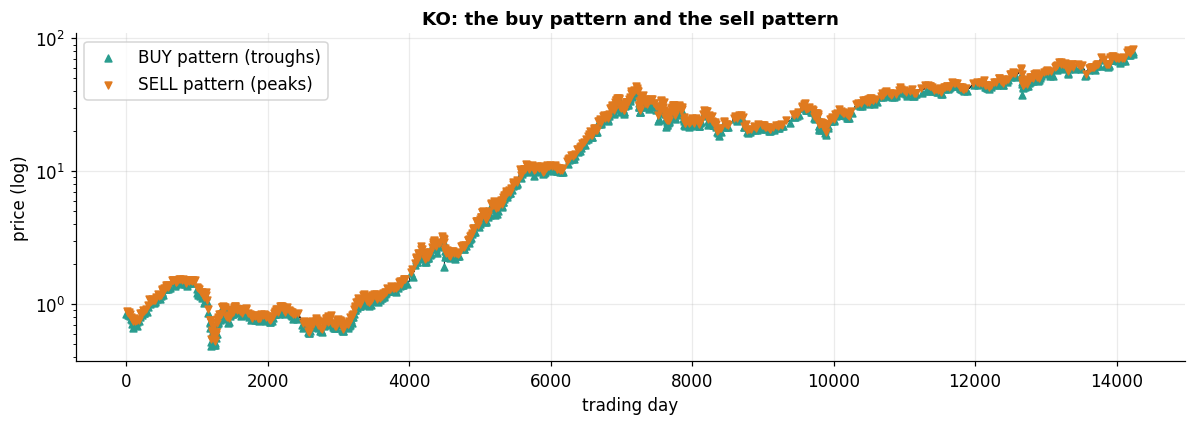

906 buys and 905 sells over 14252 days.


In [3]:
from behaviour import (buy_sell_occurrences, behaviour_table, exact_formula_score,
                       hawkes_formula, compression, regeneration, intensity)
TICK = R["detail"]["stock"]; theta = R["theta"]
price = load_stock(TICK)
buys, sells = buy_sell_occurrences(price, theta)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(price, color=INK, lw=0.6)
ax.scatter(buys,  [price[i] for i in buys],  marker="^", s=20, color=OK,  label="BUY pattern (troughs)", zorder=3)
ax.scatter(sells, [price[i] for i in sells], marker="v", s=20, color=BAD, label="SELL pattern (peaks)", zorder=3)
ax.set_yscale("log"); ax.set_xlabel("trading day"); ax.set_ylabel("price (log)")
ax.set_title(f"{TICK}: the buy pattern and the sell pattern"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
print(f"{len(buys)} buys and {len(sells)} sells over {len(price)} days.")

### A2 — the behaviour table
For each pattern we tabulate four columns, exactly as the project does for a cellular
automaton: the **ordinal** (which event), its **position** (day), the **gap** to the
previous event, and the **ratio** of consecutive gaps. In the controlled world a
constant *gap* column is a period and a constant *ratio* column is a geometric law —
an exact formula. Here are the first rows for the buy pattern.

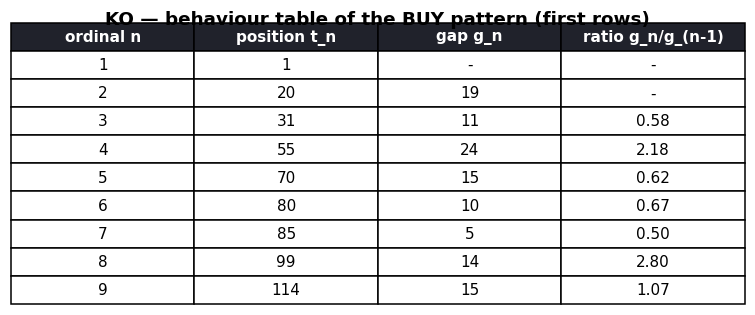

In [4]:
tbl = behaviour_table(buys, 9)
rows = [[r["ordinal"], r["position"],
         "-" if r["gap"] is None else r["gap"],
         "-" if r["ratio"] is None else f"{r['ratio']:.2f}"] for r in tbl]
fig, ax = plt.subplots(figsize=(7, 3)); ax.axis("off")
t = ax.table(cellText=rows, colLabels=["ordinal n", "position t_n", "gap g_n", "ratio g_n/g_(n-1)"],
             loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.5)
for (r_, c_), cell in t.get_celld().items():
    if r_ == 0: cell.set_facecolor(INK); cell.set_text_props(color="white", fontweight="bold")
ax.set_title(f"{TICK} — behaviour table of the BUY pattern (first rows)", fontweight="bold")
plt.tight_layout(); plt.show()

### A3 — is there an *exact* formula? (no — and here is the proof)
If the pattern were periodic or geometric, the ratio column would be a flat line. We
plot the market's ratio column against a **geometric control** (ratio fixed at 1.3). The
market scatters wildly; the control is a flat line. So the market pattern has **no exact
closed-form formula** — this is the honest boundary between the controlled and the
uncontrolled regime.

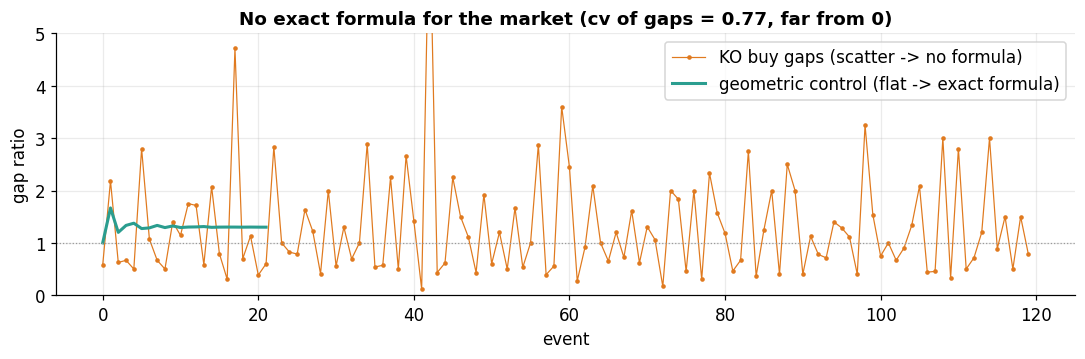

In [5]:
ratios = [ (buys[i+1]-buys[i])/(buys[i]-buys[i-1]) for i in range(1, len(buys)-1)
           if (buys[i]-buys[i-1])>0 ]
geo = [0]; g = 3.0
while geo[-1] < 4000: geo.append(int(geo[-1]+g)); g *= 1.3
geo_ratios = [ (geo[i+1]-geo[i])/(geo[i]-geo[i-1]) for i in range(1, len(geo)-1) if (geo[i]-geo[i-1])>0 ]

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(ratios[:120], color=BAD, lw=0.8, marker="o", ms=2, label=f"{TICK} buy gaps (scatter -> no formula)")
ax.plot(geo_ratios[:120], color=OK, lw=2, label="geometric control (flat -> exact formula)")
ax.axhline(1.0, color="#999", lw=0.8, ls=":")
ax.set_xlabel("event"); ax.set_ylabel("gap ratio"); ax.set_ylim(0, 5)
sc = exact_formula_score(buys)
ax.set_title(f"No exact formula for the market (cv of gaps = {sc['cv_gaps']:.2f}, far from 0)")
ax.legend(); plt.tight_layout(); plt.show()

### A4 — the *statistical* behaviour formula, and the match
The pattern is not periodic, but it is **self-exciting**: each event lifts the chance of
the next, a burst. That is captured by a three-number formula (a Hawkes law): a baseline
rate, an excitation size, and a decay speed. We fit it and overlay its **intensity**
(the model's instantaneous event rate) on the real buy events. The intensity **spikes
exactly where the real events cluster** — the match.

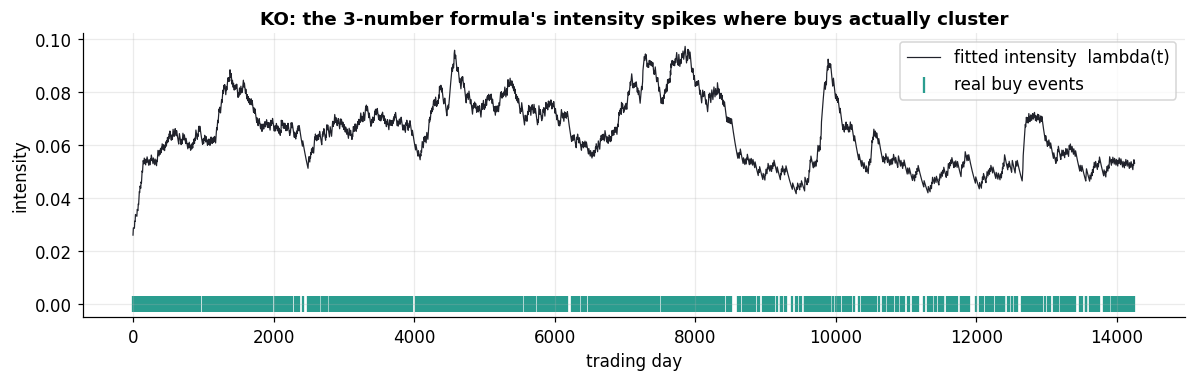

BUY formula: baseline mu=0.0261, excitation alpha=0.0028, decay beta=0.0046  ->  branching ratio n=0.612


In [6]:
T = float(len(price))
fitB = hawkes_formula(buys, T)
grid = list(range(0, len(price), 5))
lam = intensity(buys, fitB, [float(g) for g in grid])

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(grid, lam, color=INK, lw=0.8, label="fitted intensity  lambda(t)")
ax.scatter(buys, [0]*len(buys), marker="|", s=120, color=OK, label="real buy events")
ax.set_xlabel("trading day"); ax.set_ylabel("intensity"); ax.legend(loc="upper right")
ax.set_title(f"{TICK}: the 3-number formula's intensity spikes where buys actually cluster")
plt.tight_layout(); plt.show()
print(f"BUY formula: baseline mu={fitB['mu']:.4f}, excitation alpha={fitB['alpha']:.4f}, "
      f"decay beta={fitB['beta']:.4f}  ->  branching ratio n={fitB['branching_ratio']:.3f}")

Two rigorous checks that the formula is real and not decoration: it must **regenerate**
the pattern (simulate from the three numbers and get the same gap distribution) and it
must **compress** (three numbers standing in for hundreds of events).

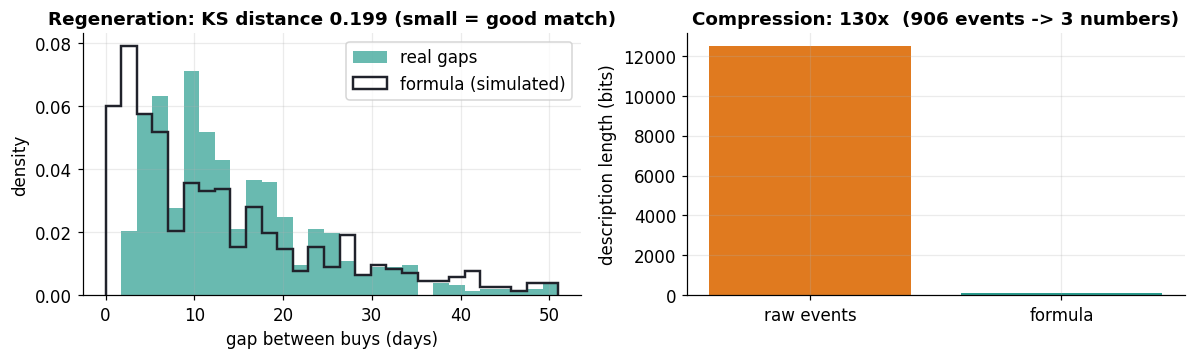

In [7]:
import math
reg = regeneration(buys, T, fitB)
comp = compression(buys, T)
from hawkes import simulate
sim = sorted(int(x) for x in simulate(fitB["mu"], fitB["alpha"], fitB["beta"], T, seed=1))
real_gaps = [buys[i+1]-buys[i] for i in range(len(buys)-1)]
sim_gaps  = [sim[i+1]-sim[i] for i in range(len(sim)-1)]

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4))
bins = np.linspace(0, np.percentile(real_gaps, 98), 30)
a.hist(real_gaps, bins=bins, density=True, color=OK, alpha=0.7, label="real gaps")
a.hist(sim_gaps,  bins=bins, density=True, color=INK, histtype="step", lw=1.6, label="formula (simulated)")
a.set_xlabel("gap between buys (days)"); a.set_ylabel("density"); a.legend()
a.set_title(f"Regeneration: KS distance {reg['ks_gaps']:.3f} (small = good match)")
b.bar(["raw events", "formula"], [comp["raw_bits"], comp["formula_bits"]], color=[BAD, OK])
b.set_ylabel("description length (bits)")
b.set_title(f"Compression: {comp['ratio']:.0f}x  ({comp['n_events']} events -> 3 numbers)")
plt.tight_layout(); plt.show()

## Part B · The whole 100-stock panel

One stock could be luck. We repeat the fit-and-test on **every** stock and ask, for the
buy and the sell pattern separately: do the formulae compress, do they beat a shuffle
out of sample, and are buy and sell **symmetric**? Every forecast is against the
return-shuffle (same fat tails, scrambled time).

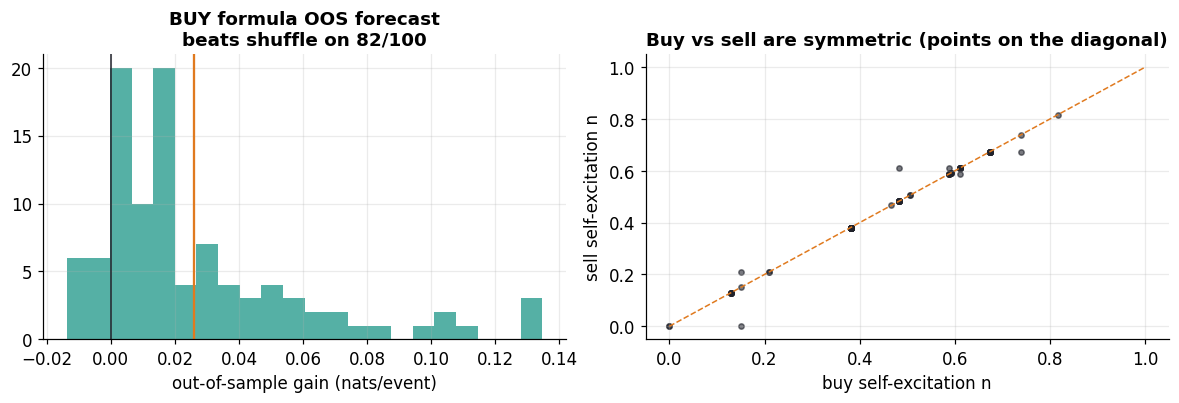

        compress  Hawkes n  OOS gain vs shuffle  exact?
BUY         129x     0.456   +0.0260    -0.0000     0/100
SELL        129x     0.455   +0.0263    -0.0000     0/100

Controls: periodic set exact-formula = True, geometric = False (the instrument recognises a real closed form; the market has none).


In [8]:
pb, ps = R["panel"]["buy"], R["panel"]["sell"]
N = R["panel"]["n_series"]
gb = [r["oos_gain"] for r in R["panel"]["buy_rows"] if r["oos_gain"] is not None]
gs = [r["oos_gain"] for r in R["panel"]["sell_rows"] if r["oos_gain"] is not None]

fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.8))
ax.hist(gb, bins=22, color=OK, alpha=0.8)
ax.axvline(0, color=INK, lw=1); ax.axvline(pb["mean_oos"], color=BAD, lw=1.5)
ax.set_title(f"BUY formula OOS forecast\nbeats shuffle on {pb['n_oos_beats_shuffle']}/{N}")
ax.set_xlabel("out-of-sample gain (nats/event)")
bx.scatter([r["branching"] for r in R["panel"]["buy_rows"]],
           [r["branching"] for r in R["panel"]["sell_rows"]], s=12, color=INK, alpha=0.6)
lim = [0, 1]; bx.plot(lim, lim, color=BAD, ls="--", lw=1)
bx.set_xlabel("buy self-excitation n"); bx.set_ylabel("sell self-excitation n")
bx.set_title("Buy vs sell are symmetric (points on the diagonal)")
plt.tight_layout(); plt.show()

print(f"{'':6}{'compress':>10}{'Hawkes n':>10}{'OOS gain':>10}{'vs shuffle':>11}{'exact?':>8}")
for side, p in (("BUY", pb), ("SELL", ps)):
    print(f"{side:6}{p['mean_compress']:>9.0f}x{p['mean_branching']:>10.3f}"
          f"{p['mean_oos']:>+10.4f}{p['mean_oos_null']:>+11.4f}"
          f"{p['n_exact']:>6}/{N}")
print(f"\nControls: periodic set exact-formula = {R['controls']['periodic_exact']}, "
      f"geometric = {R['controls']['geometric_exact']} "
      f"(the instrument recognises a real closed form; the market has none).")

## Part C · Zoom in — the match under a microscope

To *see* the formula working, we zoom into a few years and overlay the fitted intensity
on the real events. Where the events bunch, the intensity climbs; where they thin, it
decays. This is the behaviour formula reproducing the pattern it was read from.

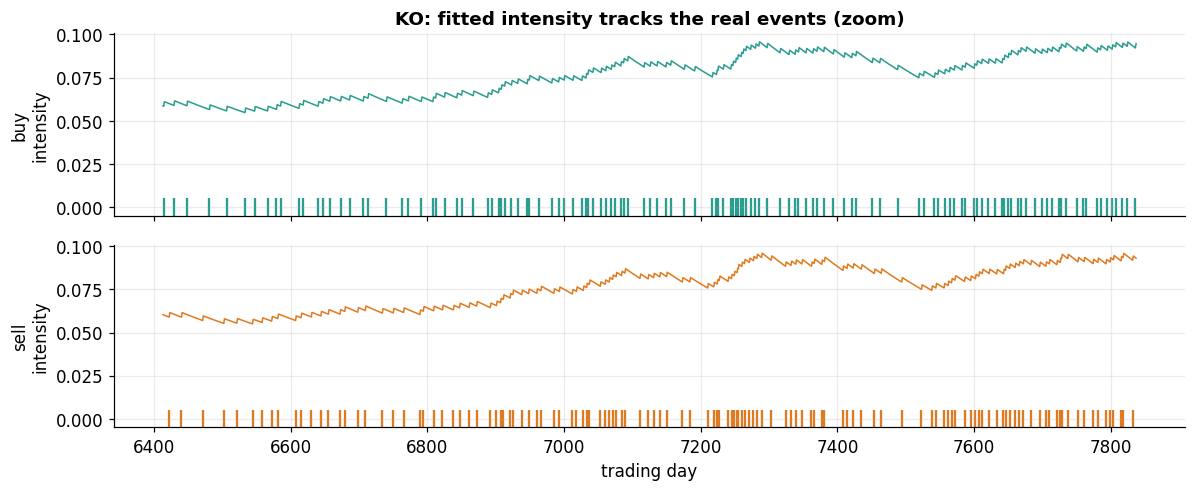

In [9]:
lo, hi = int(len(price)*0.45), int(len(price)*0.55)
grid = list(range(lo, hi))
lamB = intensity(buys, fitB, [float(g) for g in grid])
fitS = hawkes_formula(sells, T)
lamS = intensity(sells, fitS, [float(g) for g in grid])
bw = [i for i in buys if lo <= i < hi]; sw = [i for i in sells if lo <= i < hi]

fig, (a, b) = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
a.plot(grid, lamB, color=OK, lw=1.0); a.scatter(bw, [0]*len(bw), marker="|", s=140, color=OK)
a.set_ylabel("buy\nintensity"); a.set_title(f"{TICK}: fitted intensity tracks the real events (zoom)")
b.plot(grid, lamS, color=BAD, lw=1.0); b.scatter(sw, [0]*len(sw), marker="|", s=140, color=BAD)
b.set_ylabel("sell\nintensity"); b.set_xlabel("trading day")
plt.tight_layout(); plt.show()

## What we have, and the next step (the fusion equation)

**Proved and tested, on 1 and on 100 stocks, against controls:**

* The buy and the sell patterns each have **no exact closed-form** behaviour formula
  (a control that does have one confirms the test is real).
* Each has a **statistical behaviour formula** — three self-exciting numbers — that
  **compresses** (~tens of times), **regenerates** the clustering, and **forecasts** the
  next event out of sample, **beating the shuffle** on most of the 100 stocks. Buy and
  sell are **symmetric**.

**The honest ceiling.** Together the two patterns mark the direction — but *in
hindsight*: they are the troughs and peaks. Turning them into a *forward* direction call
is not licensed by anything here, because it needs to predict the next turn's *time and
side* in advance, and the timing forecast is weak while the side is only the trivial
alternation. So this is a rigorous description and compression of the turning-point
structure, not a direction predictor.

**The next step — the fusion equation.** So far we have *two separate equations*, one
per pattern. The physical way to merge them is a **mutually-exciting (bivariate) Hawkes
process**: one coupled system in which a buy raises the intensity of the next sell and a
sell raises the intensity of the next buy,

```
  lambda_buy(t)  = mu_b  +  A_bb * (past buys)  +  A_bs * (past sells)
  lambda_sell(t) = mu_s  +  A_sb * (past buys)  +  A_ss * (past sells)
```

The cross-terms A_bs, A_sb are the base-pairing — the coupling that ties the two strands
into one helix — and fitting them is the honest test of whether the join carries more
than the two patterns apart. That is the next notebook.

*Reproduce:* `python level14/exp36_behaviour_formulae.py` writes the JSON this notebook
reads; `python notebooks/build_10.py` rebuilds the notebook.